In [1]:
import numpy as np
import pandas as pd

#ML scikit learn SVR
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
  
#Plotting graph
import matplotlib.pyplot as plt

#Normalization of data
from sklearn.preprocessing import StandardScaler

#Utility Module for computing and displaying metrics
from utility_functions import metrics

import warnings
warnings.filterwarnings("ignore")

In [3]:
weather = pd.read_csv('Dataset_weather.csv',parse_dates=[0], index_col=0)

train = weather[:6098] 
test = weather[6098:] 

X_solar_train = train[['SWTDN', 'SWGDN', 'T']]
y_solar_train = train['DE_solar_generation_actual']
X_solar_test = test[['SWTDN', 'SWGDN', 'T']]
y_solar_test = test['DE_solar_generation_actual']

X_wind_train = train[['v1', 'v2', 'v_50m', 'z0']]
y_wind_train = train['DE_wind_generation_actual']
X_wind_test = test[['v1', 'v2', 'v_50m', 'z0']]
y_wind_test = test['DE_wind_generation_actual']

In [4]:
param_grid = {'C': [1, 10, 100, 1000], 
              'gamma': [0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']} 

solar_grid = GridSearchCV(SVR(), param_grid, refit = True, verbose = 3, return_train_score=True)
  
# fitting the model for grid search
solar_grid.fit(X_solar_train, y_solar_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END C=1, gamma=0.1, kernel=rbf;, score=(train=-0.328, test=0.073) total time=   2.1s
[CV 2/5] END C=1, gamma=0.1, kernel=rbf;, score=(train=-0.371, test=-0.271) total time=   2.1s
[CV 3/5] END C=1, gamma=0.1, kernel=rbf;, score=(train=-0.355, test=-0.567) total time=   2.1s
[CV 4/5] END C=1, gamma=0.1, kernel=rbf;, score=(train=-0.337, test=-0.685) total time=   2.1s
[CV 5/5] END C=1, gamma=0.1, kernel=rbf;, score=(train=-0.339, test=-0.546) total time=   2.1s
[CV 1/5] END C=1, gamma=0.01, kernel=rbf;, score=(train=-0.319, test=0.213) total time=   2.1s
[CV 2/5] END C=1, gamma=0.01, kernel=rbf;, score=(train=-0.311, test=-0.196) total time=   2.0s
[CV 3/5] END C=1, gamma=0.01, kernel=rbf;, score=(train=-0.274, test=-0.477) total time=   1.9s
[CV 4/5] END C=1, gamma=0.01, kernel=rbf;, score=(train=-0.242, test=-0.576) total time=   2.0s
[CV 5/5] END C=1, gamma=0.01, kernel=rbf;, score=(train=-0.243, test=-0.449) total

GridSearchCV(estimator=SVR(),
             param_grid={'C': [1, 10, 100, 1000],
                         'gamma': [0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             return_train_score=True, verbose=3)

In [5]:
print(solar_grid.best_params_)
  
# print how our model looks after hyper-parameter tuning
print(solar_grid.best_estimator_)

{'C': 1000, 'gamma': 0.0001, 'kernel': 'rbf'}
SVR(C=1000, gamma=0.0001)


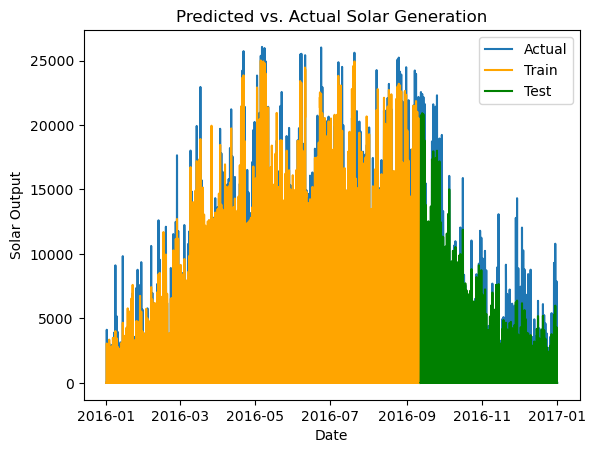

In [6]:
train_solar_pred = solar_grid.predict(X_solar_train)
test_solar_pred = solar_grid.predict(X_solar_test)

df = weather[['DE_solar_generation_actual']]

train_df = train[['DE_solar_generation_actual']]
train_df.loc[:, 'DE_solar_generation_actual'] = train_solar_pred

test_df = test[['DE_solar_generation_actual']]
test_df.loc[:, 'DE_solar_generation_actual'] = test_solar_pred

# Plot all predictions
inversetransform, =plt.plot(df, label = 'Actual')
trainpredx, =plt.plot(train_df, color='orange', label = 'Train')
testpredx, =plt.plot(test_df, color='green', label = 'Test')
plt.xlabel('Date')
plt.ylabel('Solar Output')
plt.legend(loc="upper right")
plt.title("Predicted vs. Actual Solar Generation")
plt.show()

In [7]:
metrics('svm+rbf', test[['DE_solar_generation_actual']], test_solar_pred)

,MAE,MSE,RMSE,RMSLE,R2
model,,,,,
svm+rbf,496.981448,1.312822e+06,1145.784358,7.044717,0.921213


In [8]:
param_grid = {'C': [1, 10, 100, 1000], 
              'gamma': [0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']} 

wind_grid = GridSearchCV(SVR(), param_grid, refit = True, verbose = 3, return_train_score=True)
  
# fitting the model for grid search
wind_grid.fit(X_wind_train, y_wind_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END C=1, gamma=0.1, kernel=rbf;, score=(train=0.156, test=-0.689) total time=   1.8s
[CV 2/5] END C=1, gamma=0.1, kernel=rbf;, score=(train=0.118, test=0.081) total time=   1.5s
[CV 3/5] END C=1, gamma=0.1, kernel=rbf;, score=(train=0.087, test=0.136) total time=   1.5s
[CV 4/5] END C=1, gamma=0.1, kernel=rbf;, score=(train=0.117, test=0.205) total time=   1.4s
[CV 5/5] END C=1, gamma=0.1, kernel=rbf;, score=(train=0.122, test=0.051) total time=   1.4s
[CV 1/5] END C=1, gamma=0.01, kernel=rbf;, score=(train=0.028, test=-0.712) total time=   1.6s
[CV 2/5] END C=1, gamma=0.01, kernel=rbf;, score=(train=0.041, test=0.003) total time=   1.5s
[CV 3/5] END C=1, gamma=0.01, kernel=rbf;, score=(train=0.022, test=-0.042) total time=   1.6s
[CV 4/5] END C=1, gamma=0.01, kernel=rbf;, score=(train=0.055, test=0.024) total time=   1.5s
[CV 5/5] END C=1, gamma=0.01, kernel=rbf;, score=(train=0.054, test=-0.177) total time=   1.5s


GridSearchCV(estimator=SVR(),
             param_grid={'C': [1, 10, 100, 1000],
                         'gamma': [0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             return_train_score=True, verbose=3)

In [9]:
print(wind_grid.best_params_)
  
# print how our model looks after hyper-parameter tuning
print(wind_grid.best_estimator_)

{'C': 1000, 'gamma': 0.01, 'kernel': 'rbf'}
SVR(C=1000, gamma=0.01)


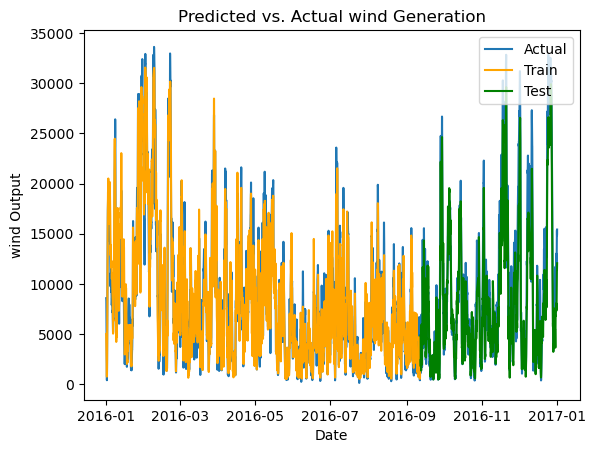

In [10]:
train_wind_pred = wind_grid.predict(X_wind_train)
test_wind_pred = wind_grid.predict(X_wind_test)

df = weather[['DE_wind_generation_actual']]

train_df = train[['DE_wind_generation_actual']]
train_df.loc[:, 'DE_wind_generation_actual'] = train_wind_pred

test_df = test[['DE_wind_generation_actual']]
test_df.loc[:, 'DE_wind_generation_actual'] = test_wind_pred

# Plot all predictions
inversetransform, =plt.plot(df, label = 'Actual')
trainpredx, =plt.plot(train_df, color='orange', label = 'Train')
testpredx, =plt.plot(test_df, color='green', label = 'Test')
plt.xlabel('Date')
plt.ylabel('wind Output')
plt.legend(loc="upper right")
plt.title("Predicted vs. Actual wind Generation")
plt.show()

In [11]:
metrics('svm+rbf', test[['DE_wind_generation_actual']], test_wind_pred)

,MAE,MSE,RMSE,RMSLE,R2
model,,,,,
svm+rbf,1748.838366,5.772712e+06,2402.646929,7.784742,0.898474
